In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from datetime import datetime
import glob

In [17]:
data_files = glob.glob('../data/*.csv')
all_data = []

for file in data_files:
    df = pd.read_csv(file)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    all_data.append(df)

combined_data = pd.concat(all_data)

In [18]:
# for i, df in enumerate(all_data):
#     plt.figure(figsize=(12, 8))
#     plt.suptitle(f'Subject {i+1} - Physiological Signals Over Time by Phase', fontsize=10)

#     plt.subplot(4, 1, 1)
#     sns.scatterplot(data=df, x='relative_time', y='hr', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
#     plt.title('Heart Rate Over Time', fontsize=8)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

#     plt.subplot(4, 1, 2)
#     sns.scatterplot(data=df, x='relative_time', y='temp', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
#     plt.title('Temperature Over Time', fontsize=8)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

#     plt.subplot(4, 1, 3)
#     sns.scatterplot(data=df, x='relative_time', y='eda', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
#     plt.title('EDA Over Time', fontsize=8)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

#     plt.subplot(4, 1, 4)
#     sns.scatterplot(data=df, x='relative_time', y='bvp', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
#     plt.title('BVP Over Time', fontsize=8)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

#     plt.tight_layout()
#     plt.show()

In [19]:
# Calculate baseline statistics with outlier removal for each signal and subject
baseline_stats = {}
signals = ['hr', 'temp', 'eda', 'bvp']  # Define signals list that was missing

for file_data, file_path in zip(all_data, data_files):
    # Get filename for identifying subject
    filename = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
    
    # Get baseline data
    baseline_data = file_data[file_data['phase'] == 'baseline']
    
    if not baseline_data.empty:
        baseline_stats[filename] = {}
        
        for signal in signals:
            # Calculate quartiles for outlier detection
            Q1 = baseline_data[signal].quantile(0.25)
            Q3 = baseline_data[signal].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define outlier bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Remove outliers
            clean_baseline = baseline_data[
                (baseline_data[signal] >= lower_bound) & 
                (baseline_data[signal] <= upper_bound)
            ]
            
            # Store cleaned baseline statistics
            baseline_stats[filename][signal] = {
                'mean': clean_baseline[signal].mean(),
                'std': clean_baseline[signal].std(),
                'median': clean_baseline[signal].median()
            }

# Create lists to store data for DataFrame
subjects = []
signals_list = []
means = []
stds = []
medians = []

# Populate lists from baseline_stats dictionary
for subject in baseline_stats:
    for signal in baseline_stats[subject]:
        subjects.append(subject)
        signals_list.append(signal)
        means.append(baseline_stats[subject][signal]['mean'])
        stds.append(baseline_stats[subject][signal]['std']) 
        medians.append(baseline_stats[subject][signal]['median'])

# Create DataFrame
baseline_df = pd.DataFrame({
    'subject': subjects,
    'signal': signals_list,
    'mean': means,
    'std': stds,
    'median': medians
})

baseline_df[baseline_df['subject'] == 'f01']

,subject,signal,mean,std,median
0,f01,hr,71.145228,2.421028,70.345000
1,f01,temp,29.982285,0.141176,29.950000
2,f01,eda,0.180036,0.042360,0.157795
3,f01,bvp,-0.366490,19.668966,1.307187


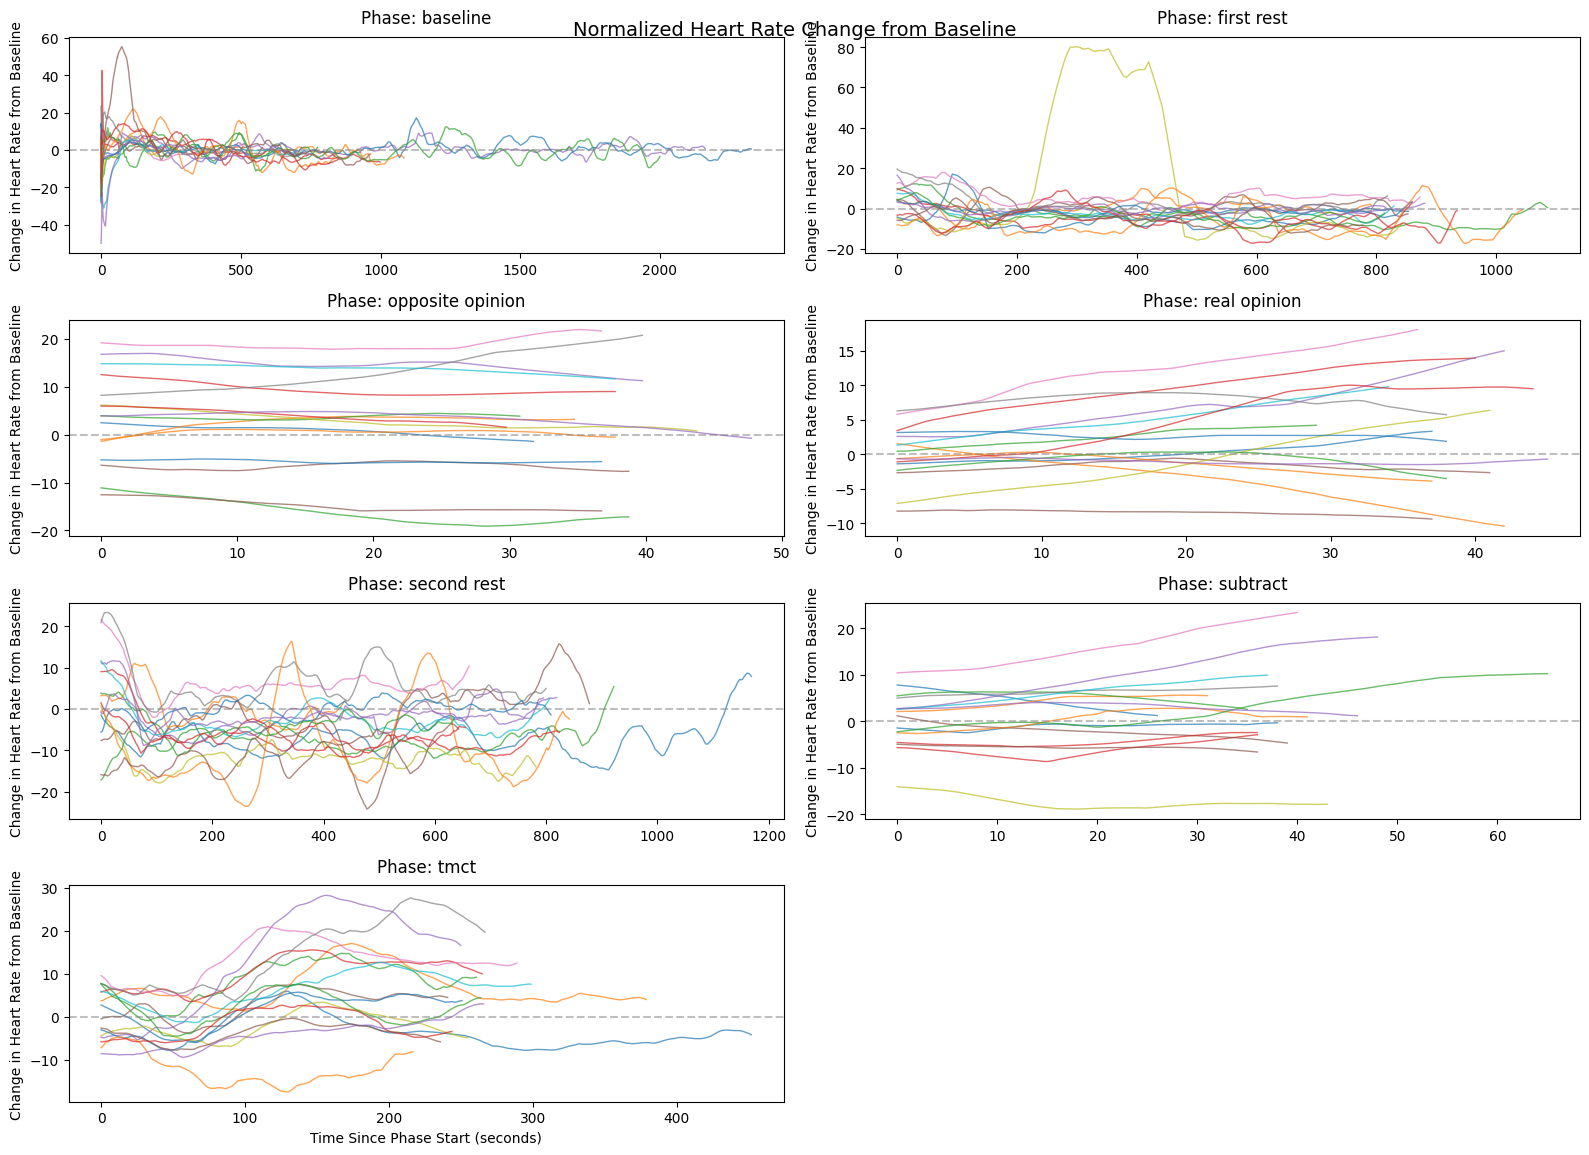

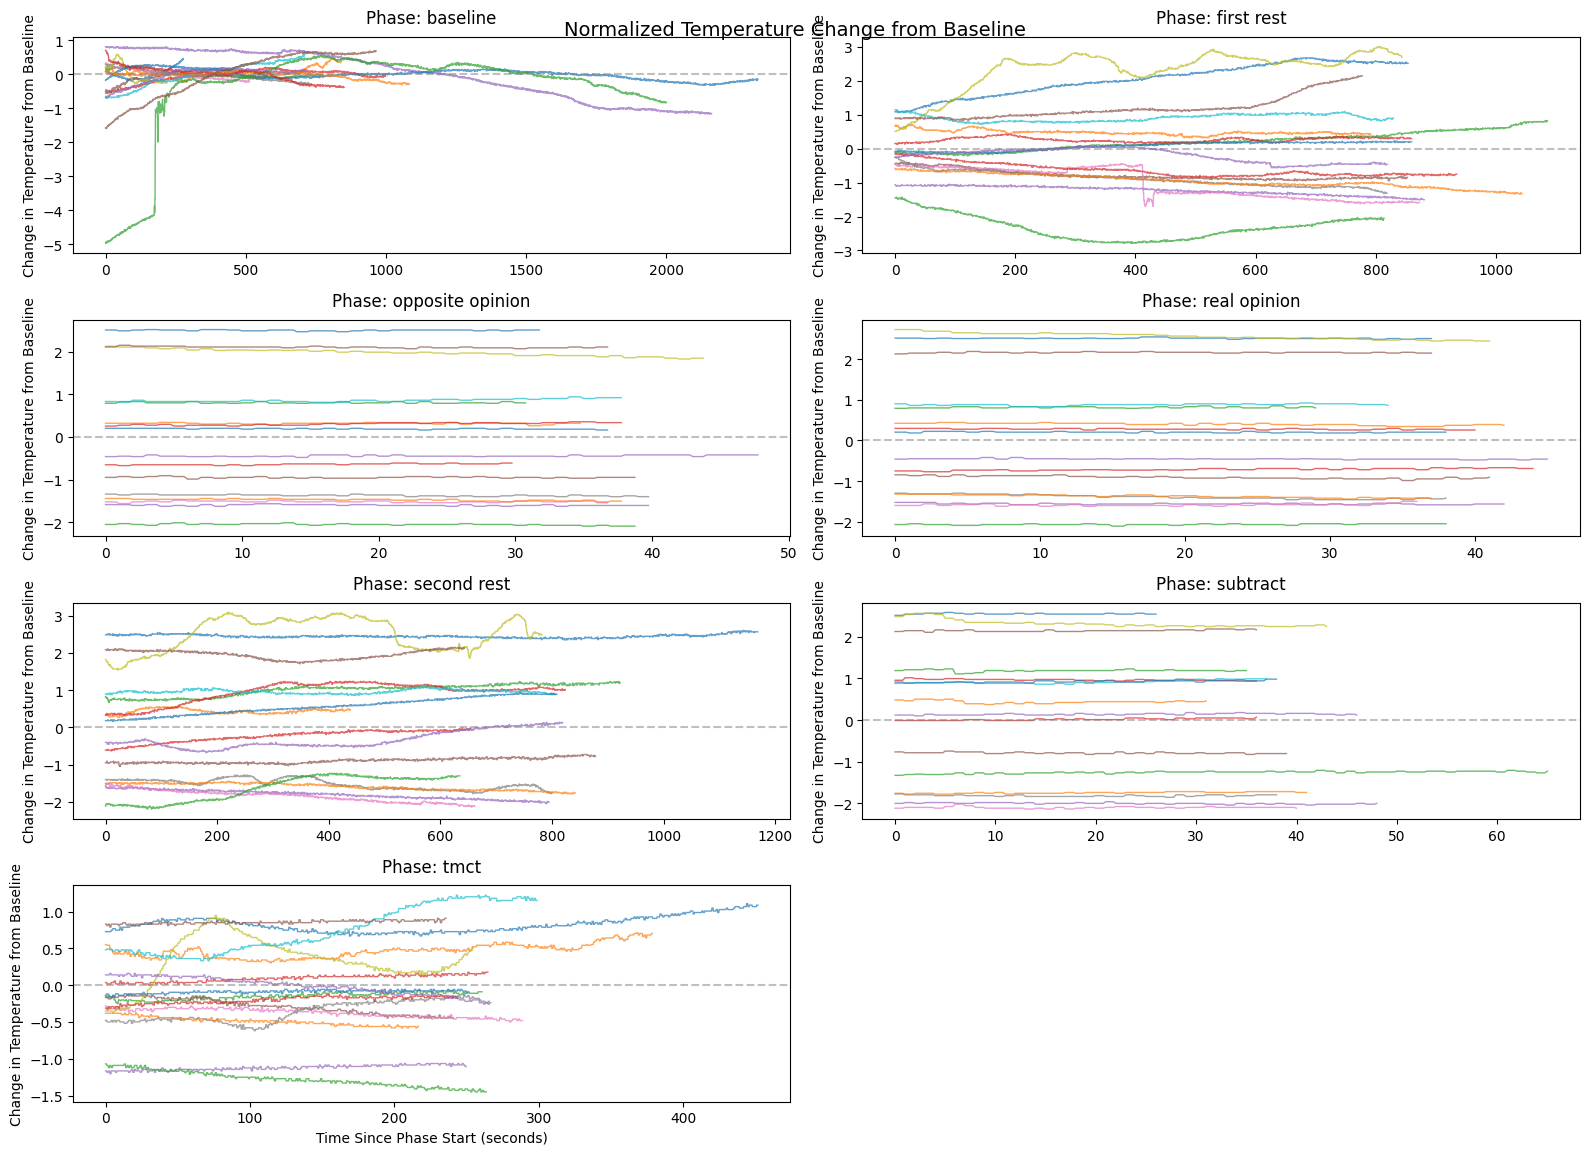

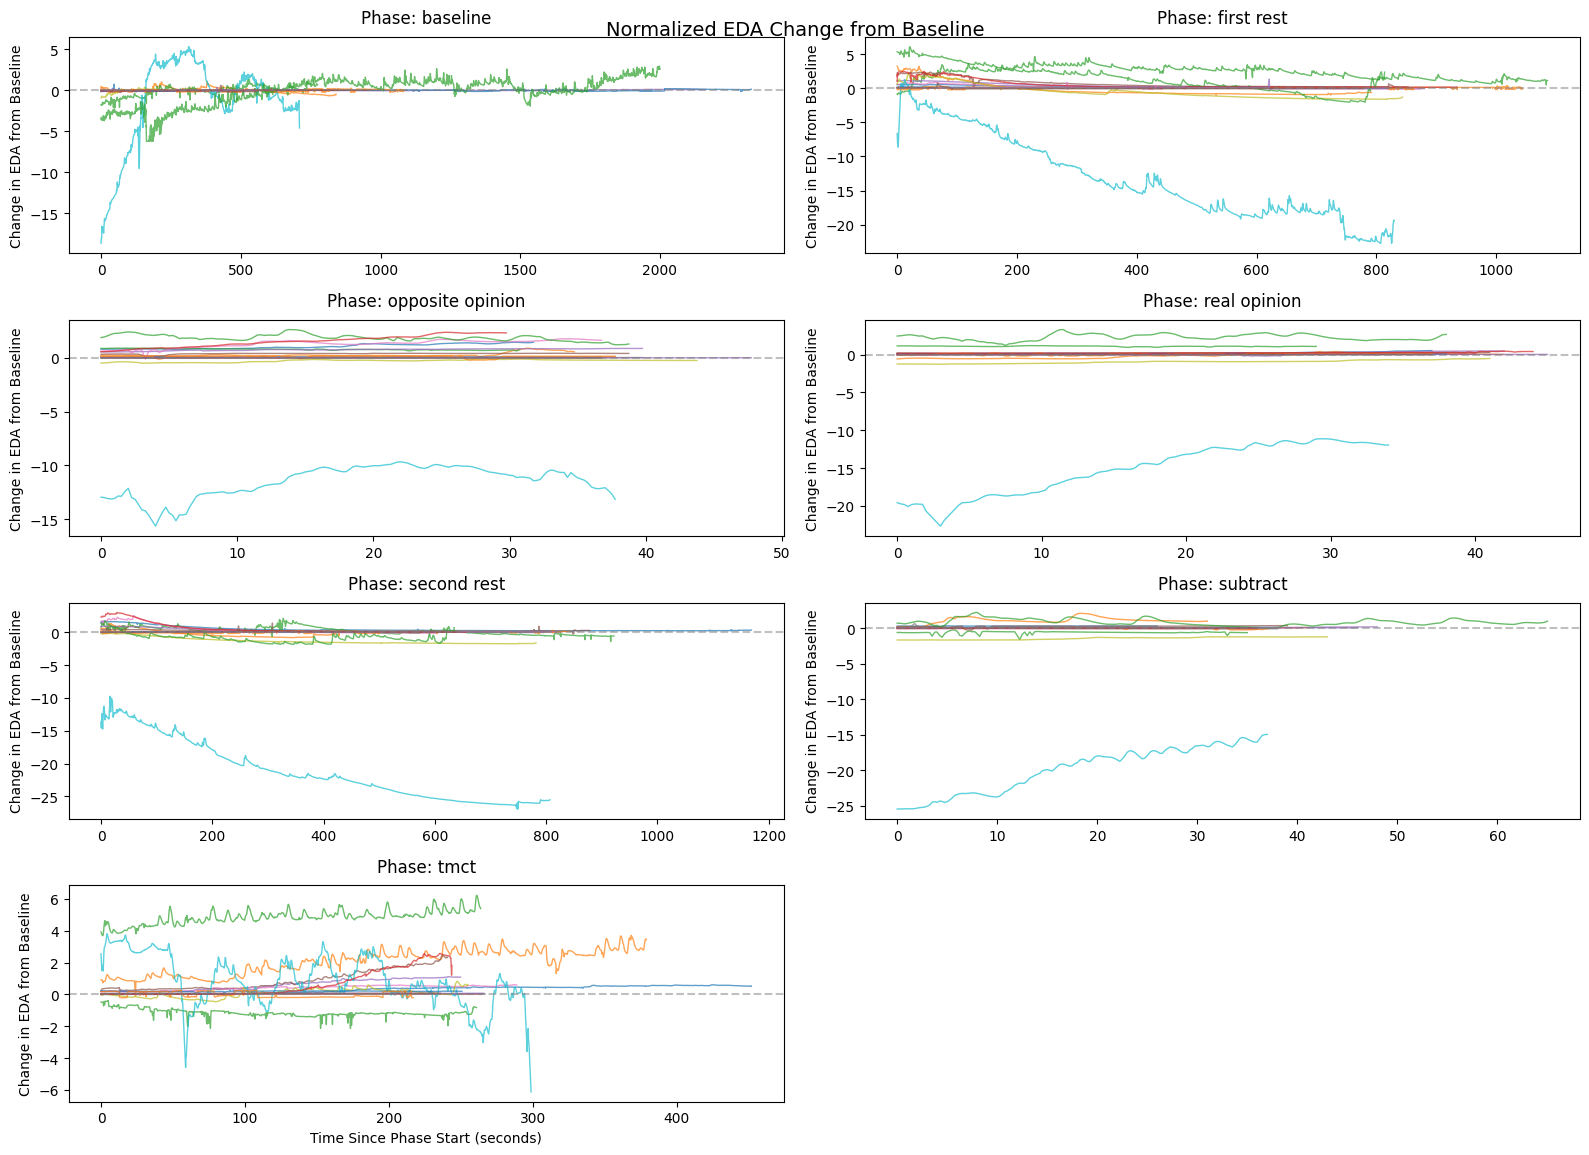

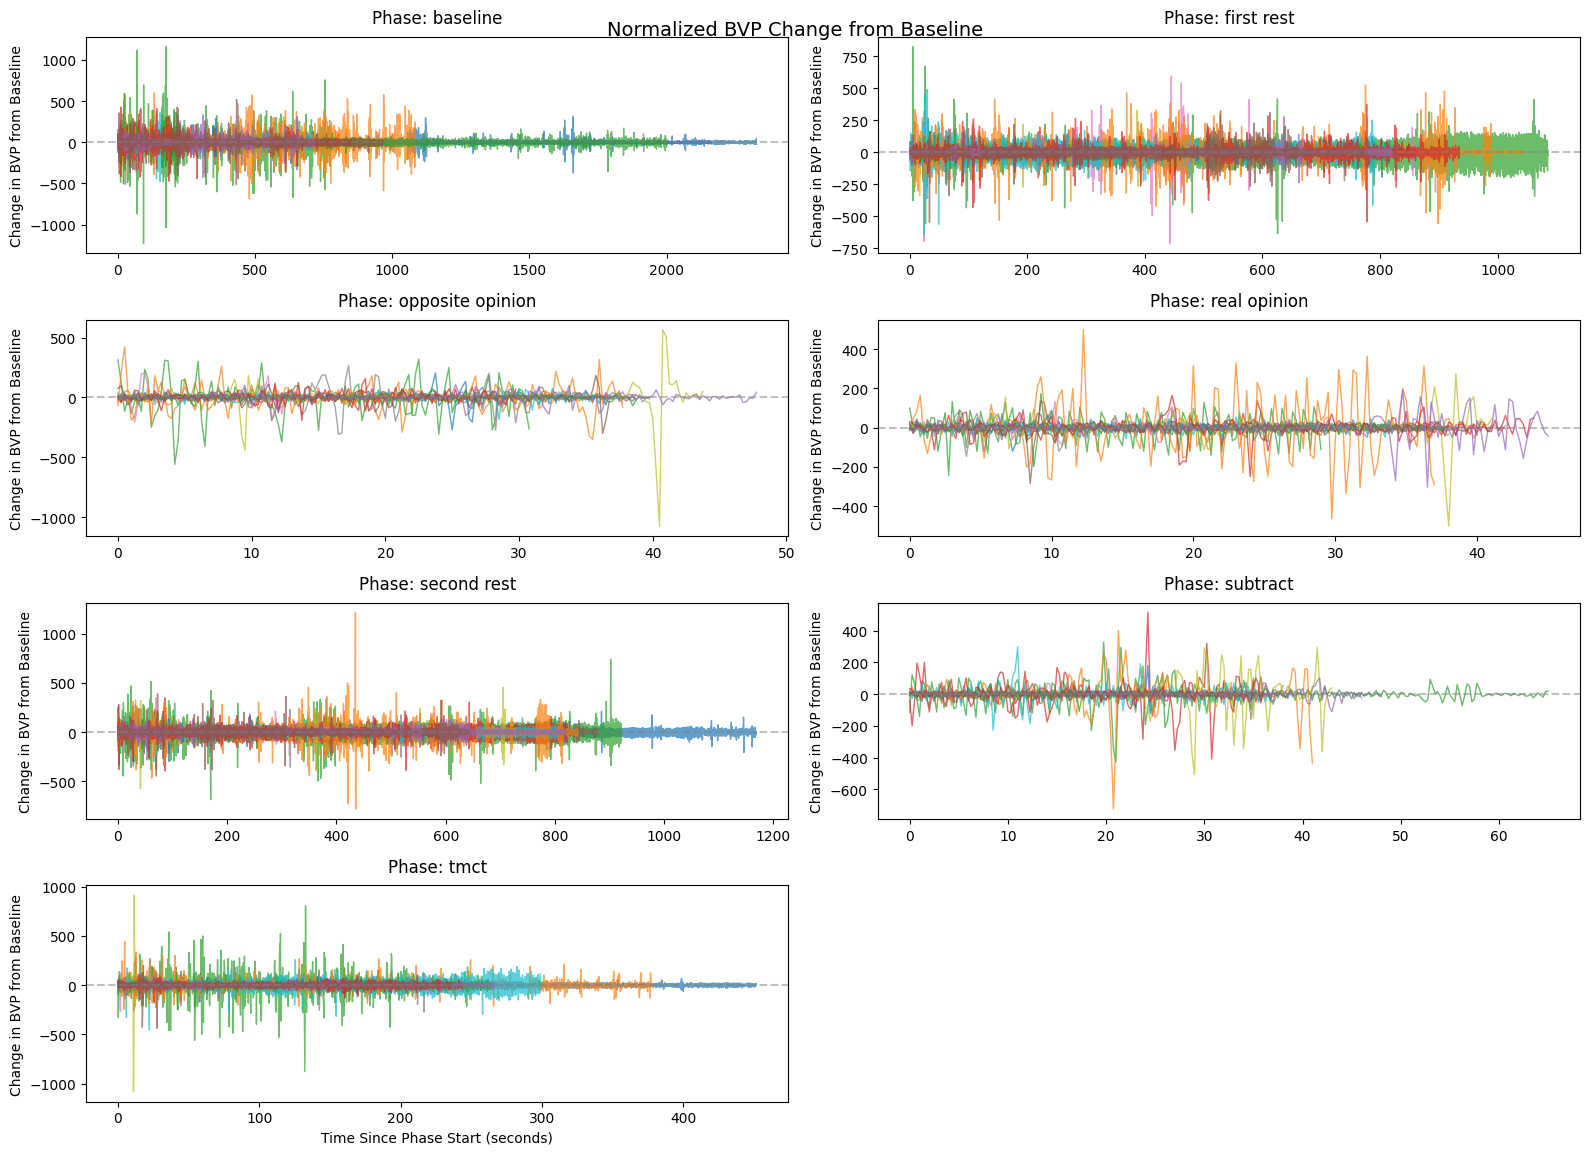

In [20]:
# Create separate figures for each physiological signal
signals = ['hr', 'temp', 'eda', 'bvp']
signal_names = ['Heart Rate', 'Temperature', 'EDA', 'BVP']

for signal, signal_name in zip(signals, signal_names):
    # Get unique phases excluding 'no phase'
    phases = sorted([p for p in combined_data['phase'].unique() if p != 'no phase' and pd.notna(p)])
    
    # Create subplot for each phase
    plt.figure(figsize=(16, 12))  # Increased figure size
    plt.suptitle(f'Normalized {signal_name} Change from Baseline', fontsize=14, y=0.95)  # Adjusted title position
    
    for i, phase in enumerate(phases, 1):
        ax = plt.subplot(4, 2, i)
        
        # Get data for this phase
        phase_data = combined_data[combined_data['phase'] == phase]
        
        # Plot each individual's data as a separate line
        for file_data, file_path in zip(all_data, data_files):
            file_phase_data = file_data[file_data['phase'] == phase]
            if not file_phase_data.empty:
                # Reset relative time to start at 0 for this phase
                phase_start_time = file_phase_data['relative_time'].min()
                aligned_time = file_phase_data['relative_time'] - phase_start_time
                
                # Get subject ID from filename
                filename = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
                
                # Get baseline statistics for this subject and signal
                subject_baseline = baseline_stats[filename][signal]['mean']
                
                # Calculate change from baseline
                normalized_values = file_phase_data[signal] - subject_baseline
                
                plt.plot(aligned_time, 
                        normalized_values,
                        alpha=0.7, 
                        linewidth=1)
        
        plt.title(f'Phase: {phase}', fontsize=12, pad=10)
        plt.ylabel(f'Change in {signal_name} from Baseline', fontsize=10)
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # Add reference line at 0
        if i > 6:  # Only show x-label for bottom row
            plt.xlabel('Time Since Phase Start (seconds)', fontsize=10)
    
    plt.tight_layout()
    plt.show()


Added observed stress levels to ../data/f01.csv
Added observed stress levels to ../data/f02.csv
Added observed stress levels to ../data/f03.csv
Added observed stress levels to ../data/f04.csv
Added observed stress levels to ../data/f05.csv
Added observed stress levels to ../data/f06.csv
Added observed stress levels to ../data/f08.csv
Added observed stress levels to ../data/f09.csv
Added observed stress levels to ../data/f10.csv
Added observed stress levels to ../data/f11.csv
Added observed stress levels to ../data/f12.csv
Added observed stress levels to ../data/f13.csv
Added observed stress levels to ../data/f15.csv
Added observed stress levels to ../data/f16.csv
Added observed stress levels to ../data/f17.csv
Added observed stress levels to ../data/f18.csv


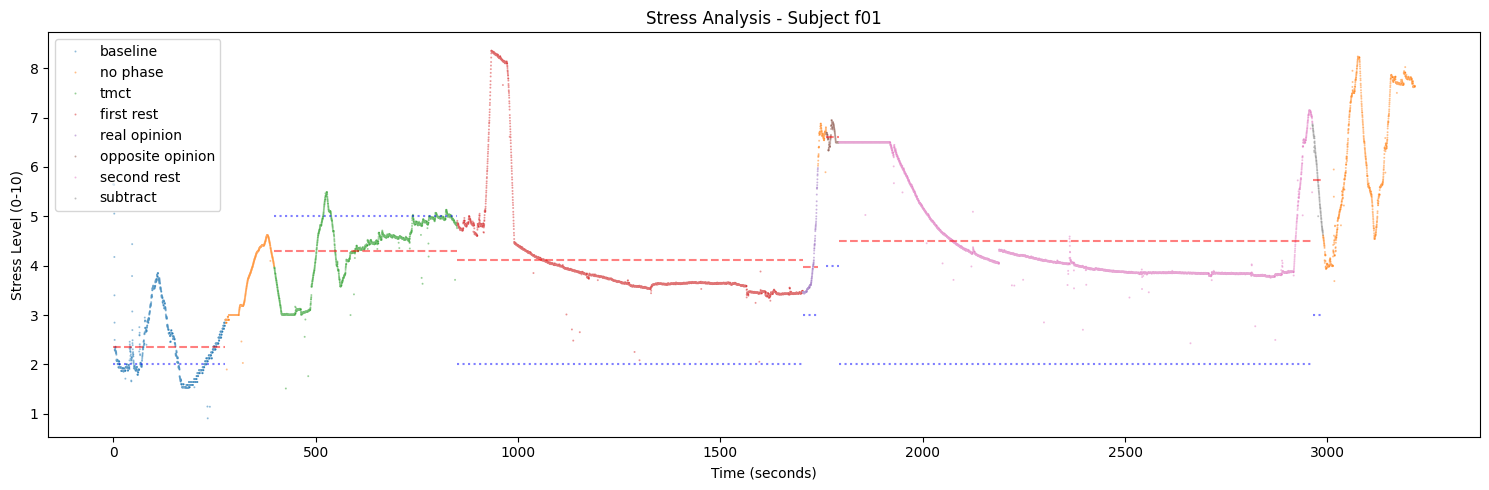

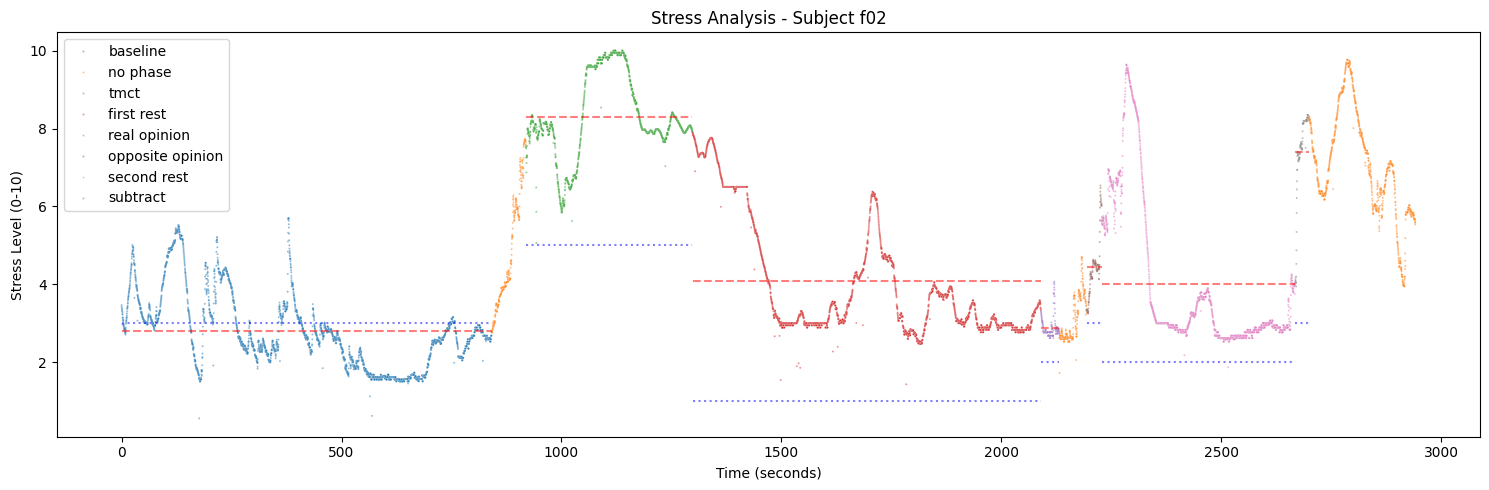

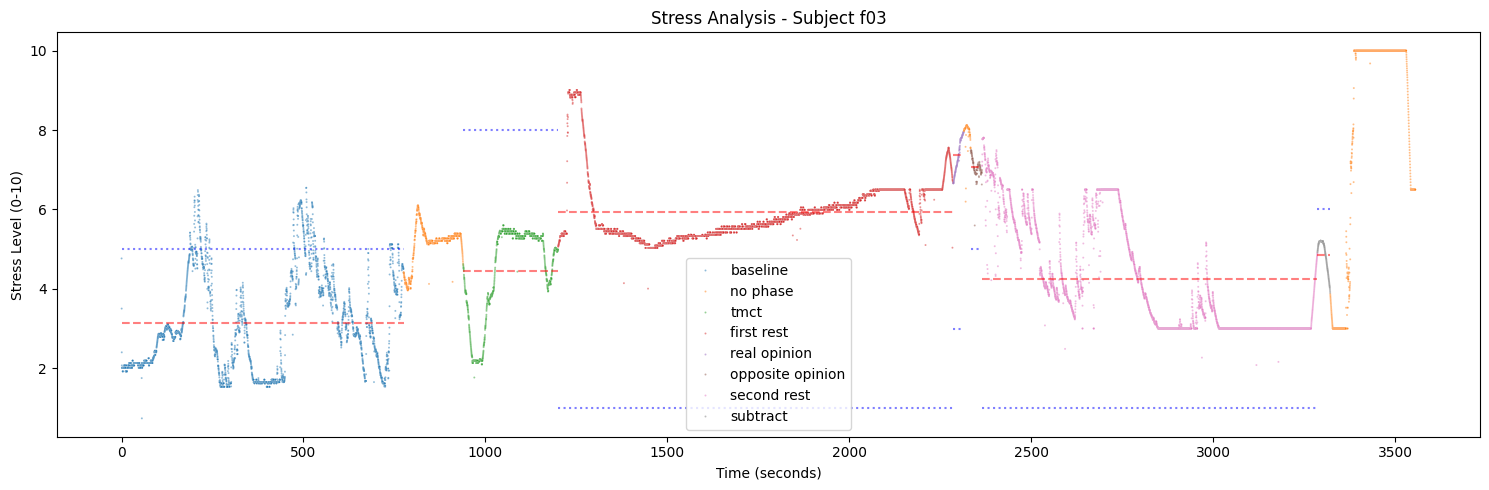

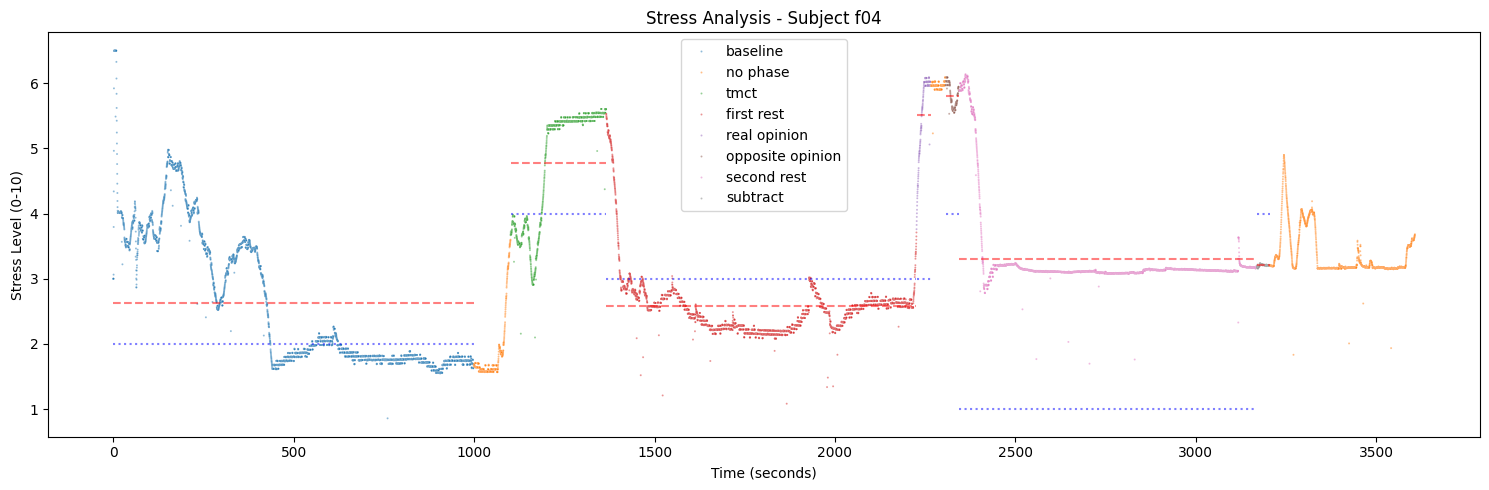

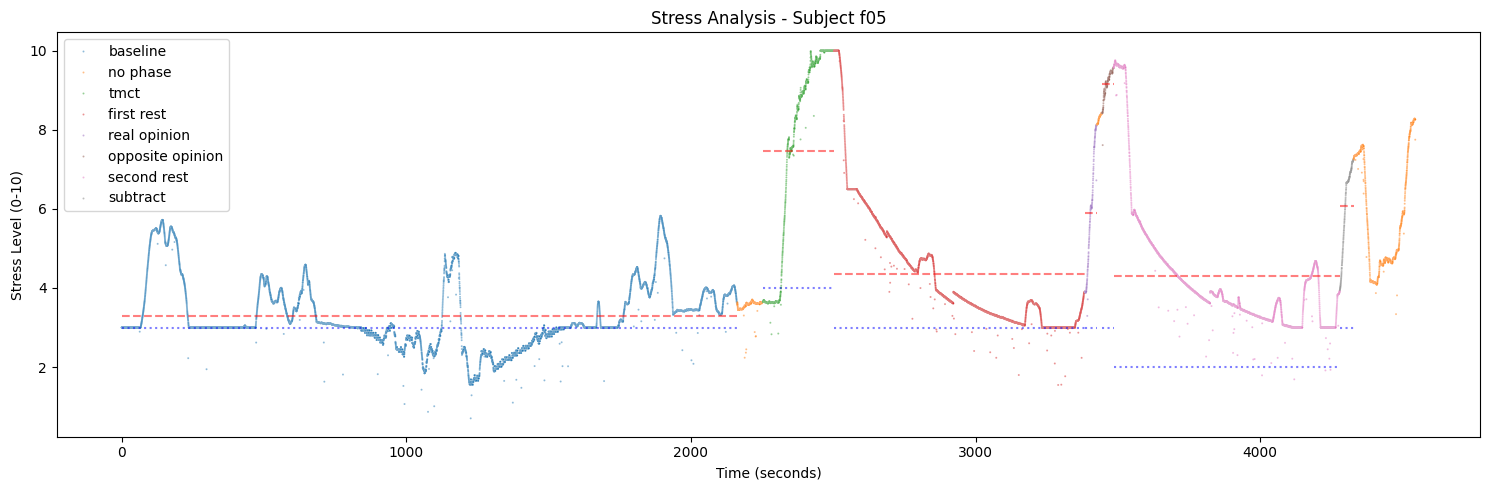

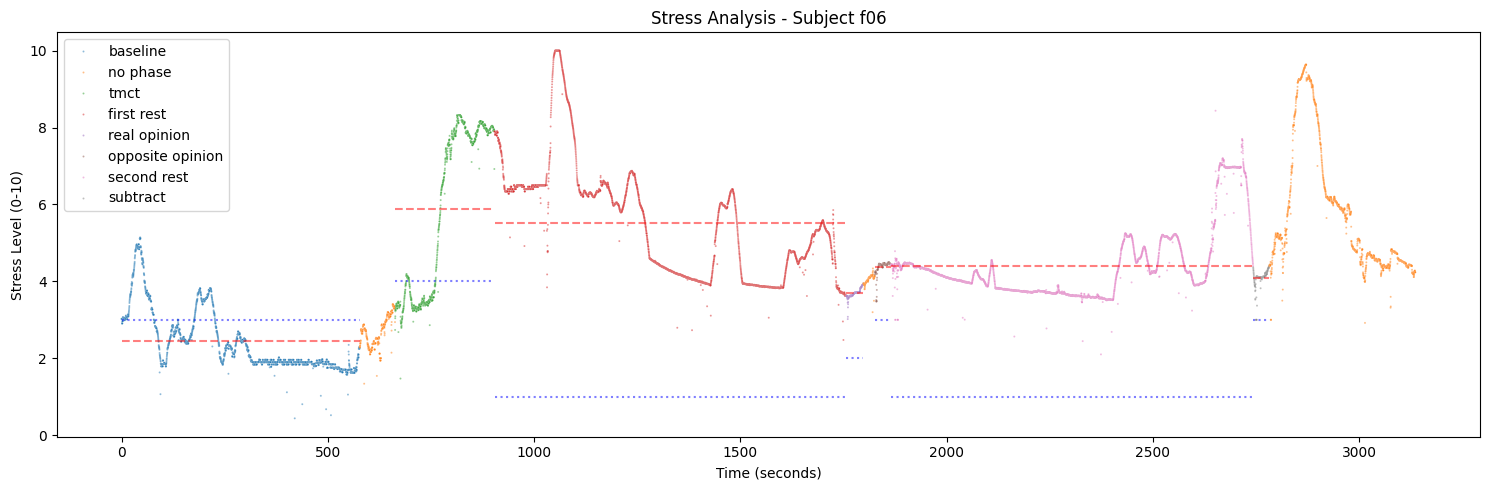

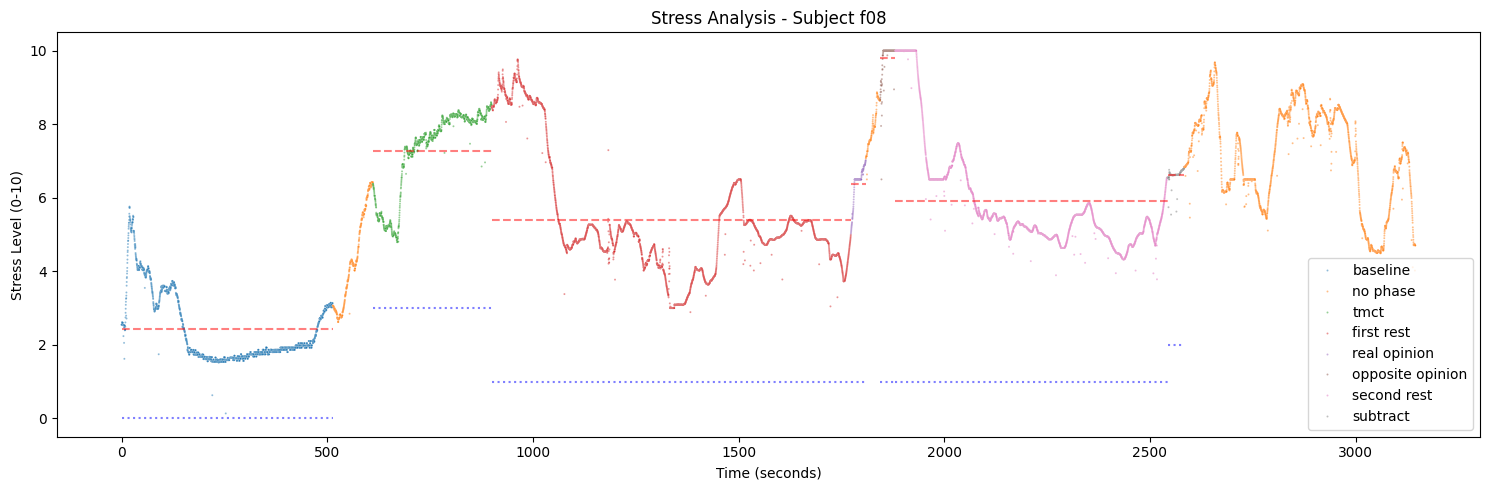

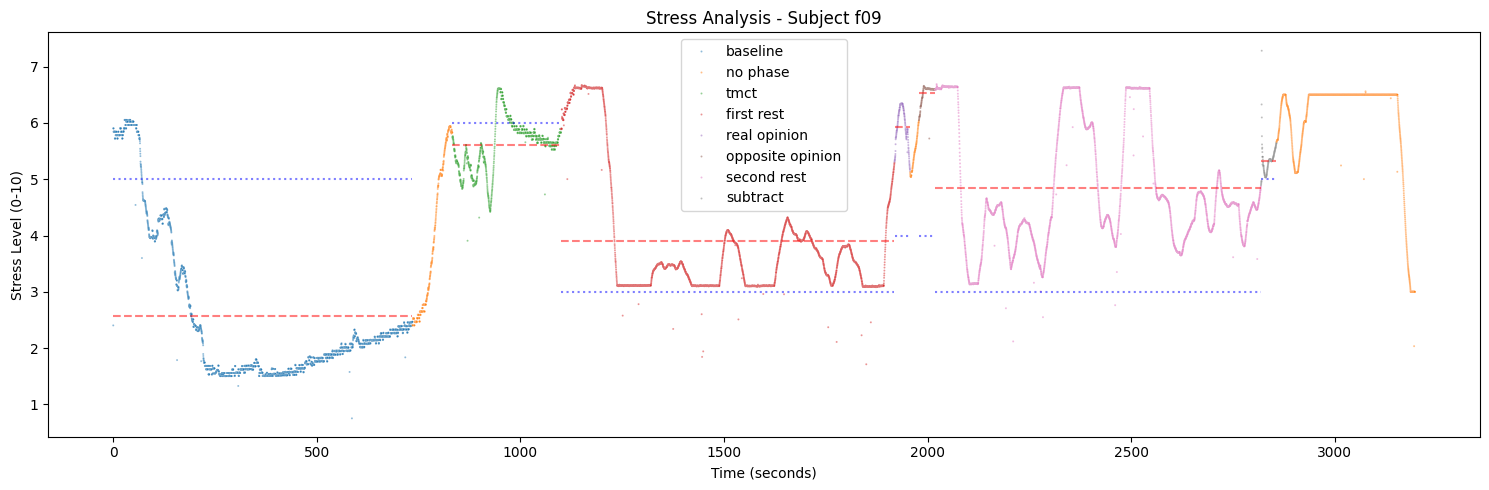

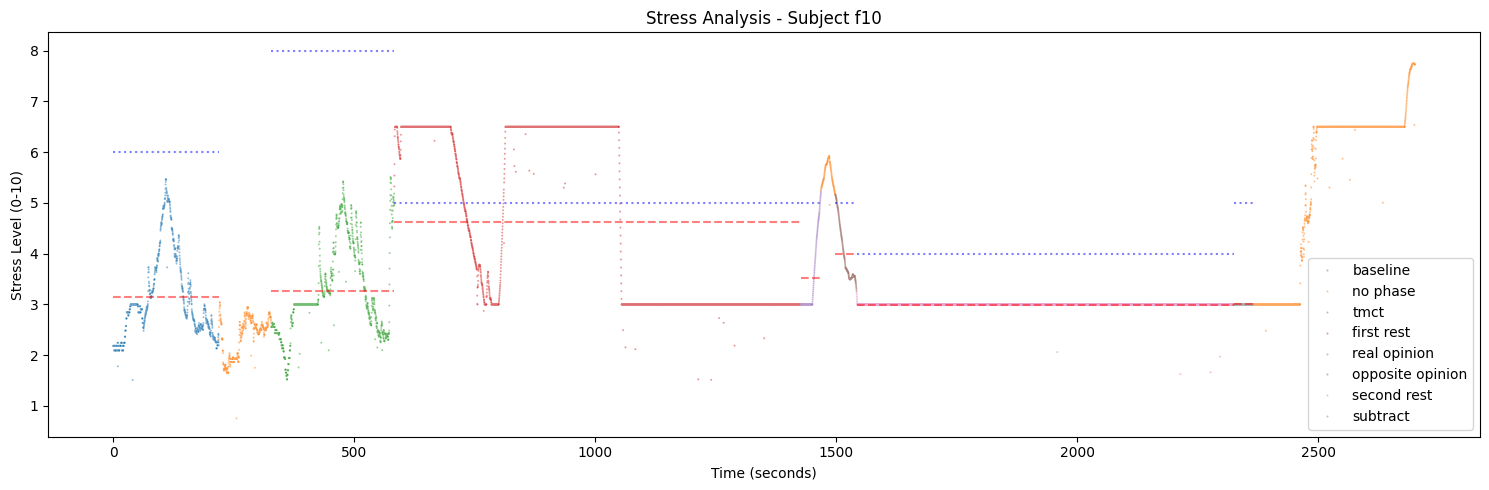

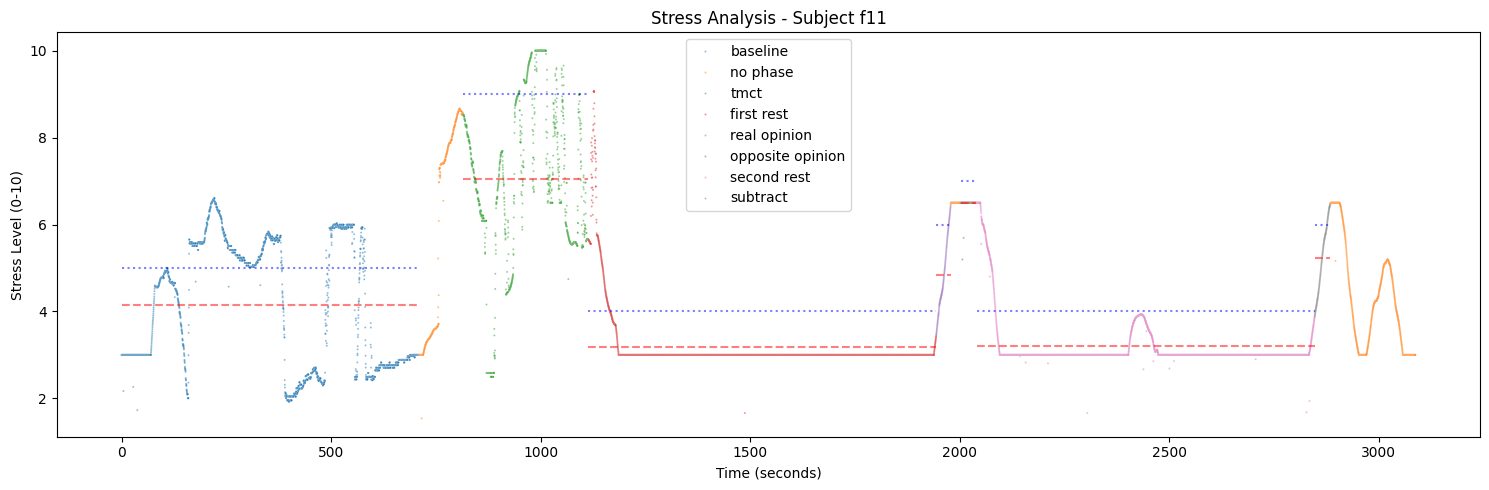

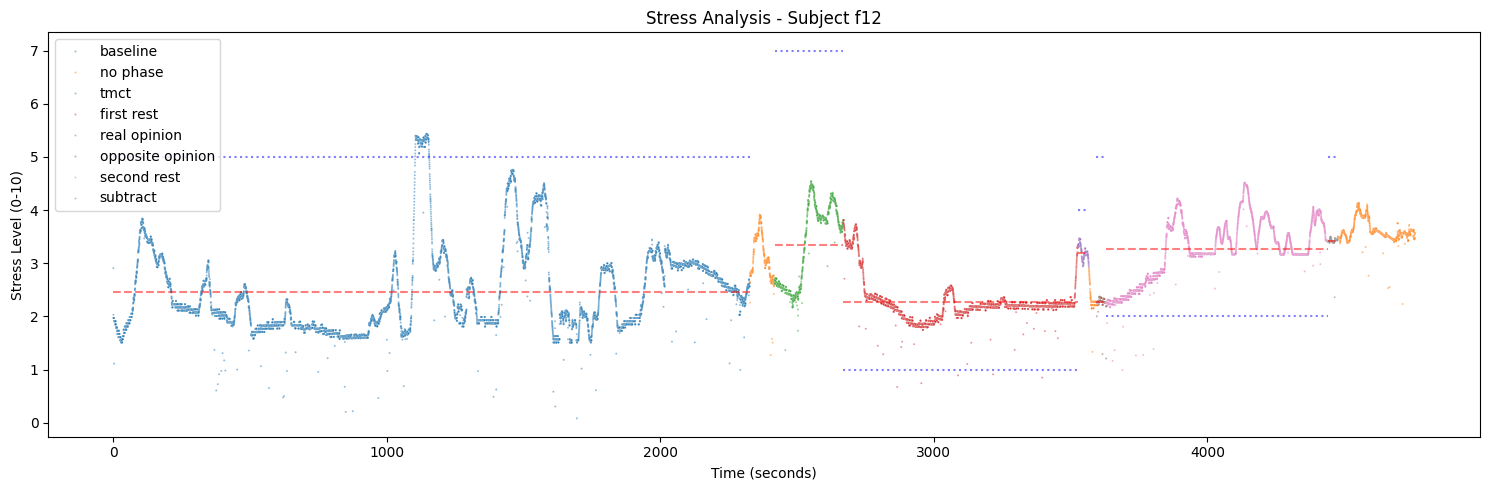

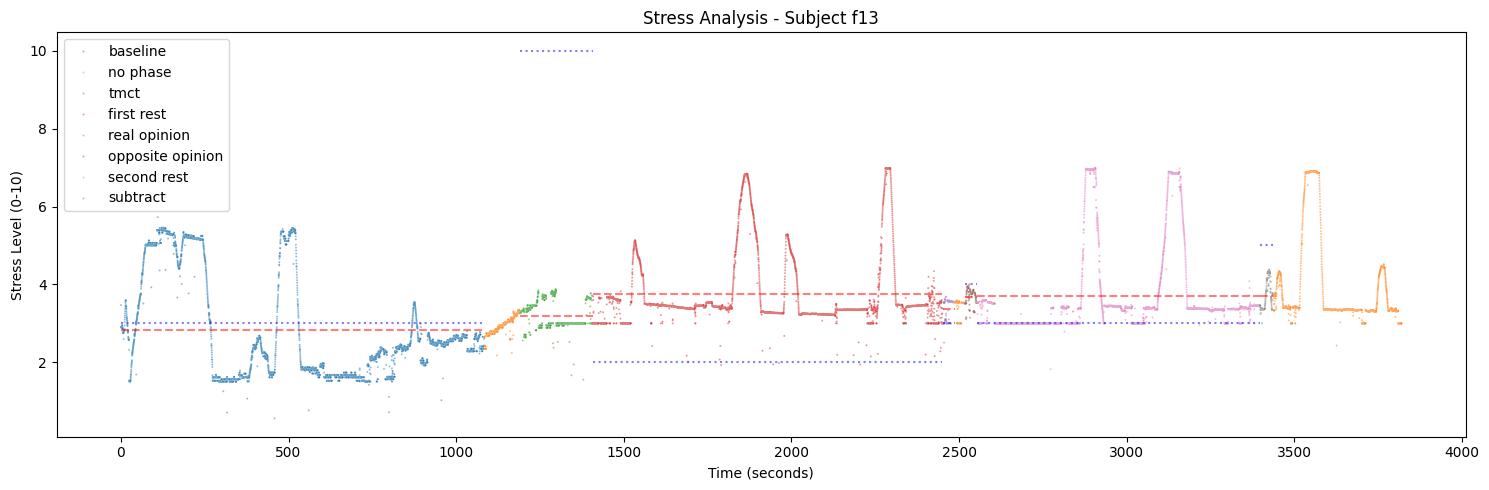

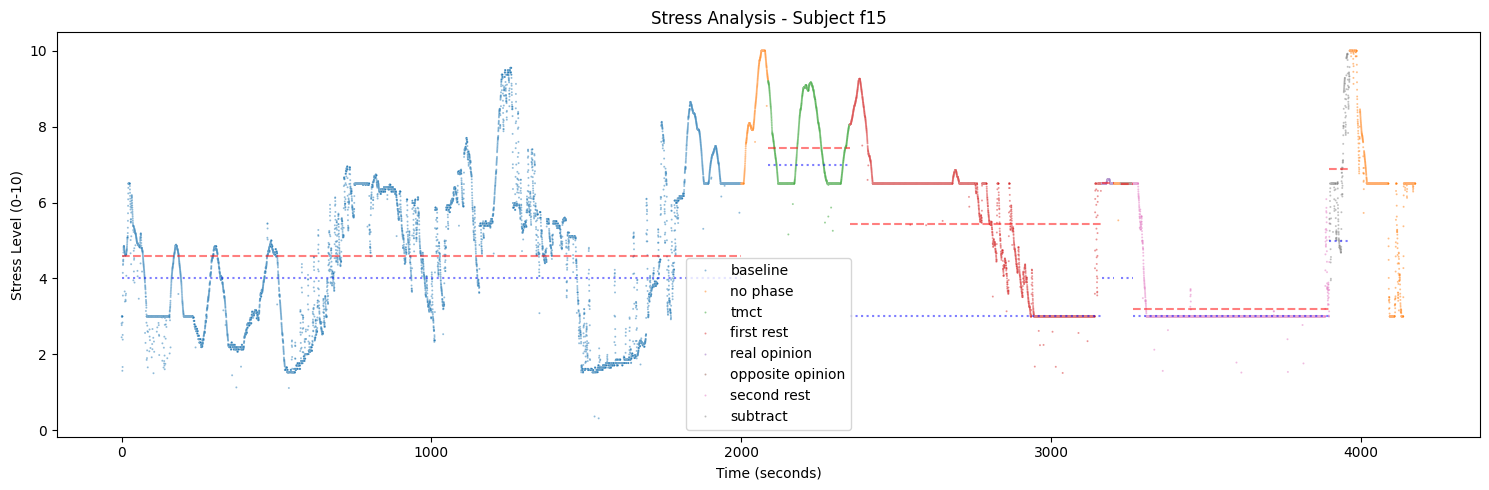

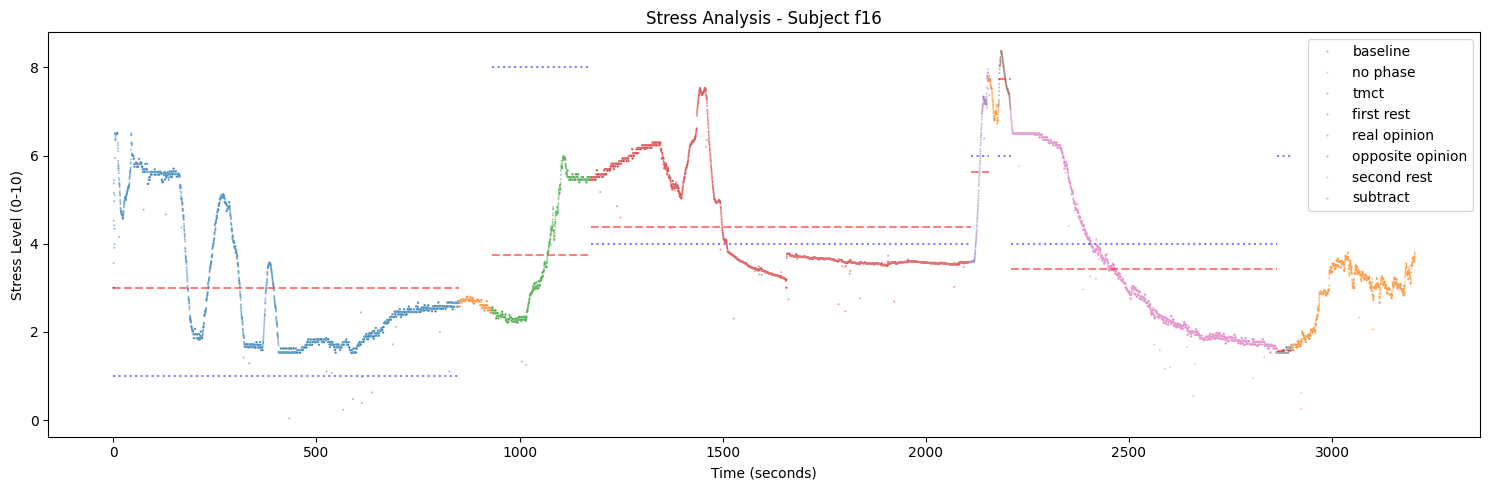

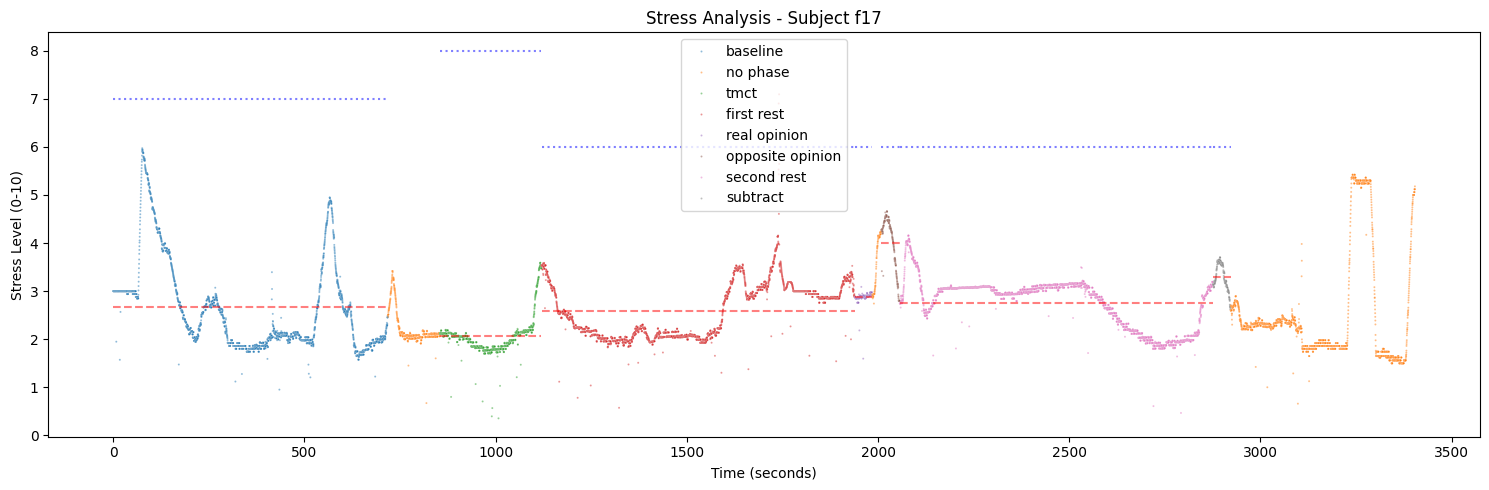

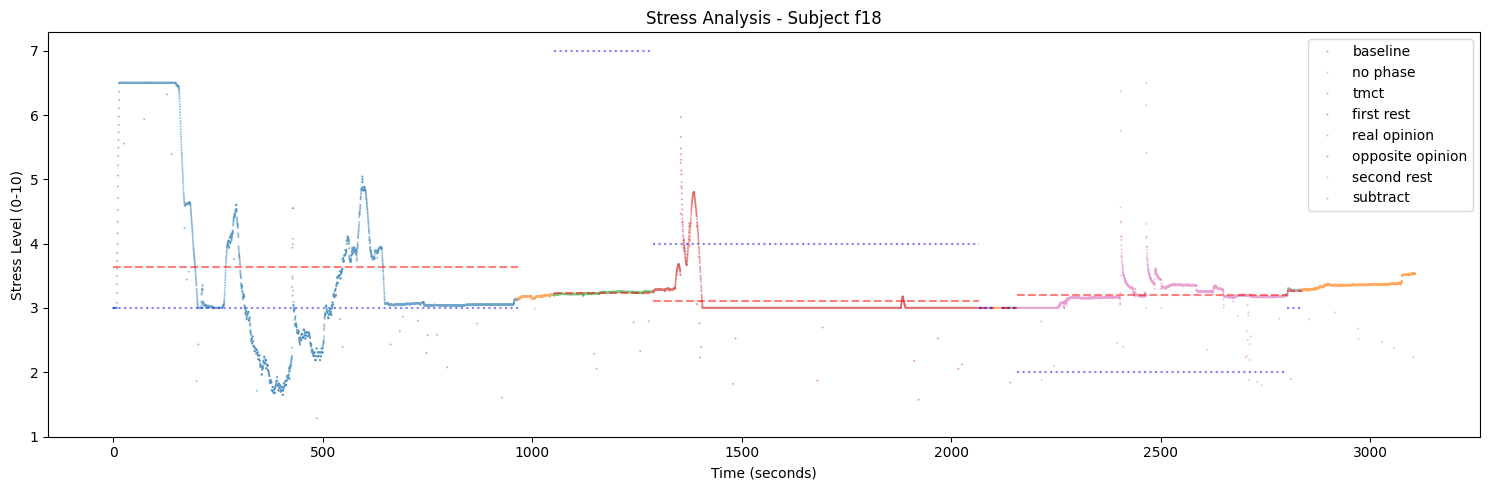

phase,baseline,first rest,no phase,opposite opinion,real opinion,second rest,subtract,tmct
subject,,,,,,,,
f01,2.360799,4.117442,5.491706,6.615952,3.981340,4.503852,5.739004,4.301697
f02,2.788569,4.076465,5.960559,4.449163,2.885885,4.003335,7.407092,8.305919
f03,3.128226,5.938303,6.895093,7.057856,7.368691,4.238868,4.864795,4.455001
f04,2.628085,2.580606,3.292617,5.810161,5.515771,3.300398,3.204863,4.780840
f05,3.299565,4.361538,5.317317,9.162246,5.895574,4.292699,6.065327,7.464794
f06,2.441723,5.527419,5.130578,4.367119,3.690428,4.407573,4.089029,5.876893
f08,2.428062,5.404608,6.775296,9.789741,6.373766,5.920788,6.624911,7.279159
f09,2.570056,3.904935,5.591525,6.523244,5.935108,4.851129,5.324124,5.607643
f10,3.139890,4.630831,4.713195,4.003790,3.528672,2.998752,3.000000,3.274122


In [21]:
def calculate_improved_stress_level(df, baseline_stats, subject_id):
    """
    Calculate stress level using robust normalization and physiological thresholds.
    
    Args:
        df: DataFrame containing physiological signals
        baseline_stats: Dictionary containing baseline statistics for each subject
        subject_id: ID of the subject being processed
    
    Returns:
        DataFrame with added stress_level column
    """
    df = df.copy()
    
    # Define physiological thresholds for significant changes
    # These represent meaningful deviations from baseline based on literature
    thresholds = {
        'hr': {
            'moderate': 10,  # 10 bpm increase from baseline
            'high': 20       # 20 bpm increase from baseline
        },
        'eda': {
            'moderate': 1,   # 1 μS increase from baseline
            'high': 2        # 2 μS increase from baseline
        },
        'temp': {
            'moderate': 0.5, # 0.5°C change from baseline
            'high': 1.0      # 1.0°C change from baseline
        },
        'bvp': {
            'moderate': 0.2, # 20% change from baseline
            'high': 0.4      # 40% change from baseline
        }
    }
    
    # Initialize component scores
    components = {}
    subject_baseline = baseline_stats[subject_id]
    
    for signal in ['hr', 'eda', 'temp', 'bvp']:
        baseline_mean = subject_baseline[signal]['mean']
        changes = df[signal] - baseline_mean
        
        # Calculate normalized stress component (0-1 scale)
        if signal in ['hr', 'eda']:
            # For HR and EDA, only increases indicate stress
            components[signal] = np.clip(
                changes / (thresholds[signal]['high'] - thresholds[signal]['moderate']),
                0, 1
            )
        else:
            # For temp and BVP, any deviation indicates stress
            components[signal] = np.clip(
                np.abs(changes) / (thresholds[signal]['high'] - thresholds[signal]['moderate']),
                0, 1
            )
    
    # Apply robust weights that sum to 1
    weights = {
        'hr': 0.35,   # Heart rate is a primary indicator
        'eda': 0.35,  # EDA is a primary indicator
        'temp': 0.15, # Temperature is secondary
        'bvp': 0.15   # BVP is secondary
    }
    
    # Calculate composite stress score (0-1 scale)
    stress_score = sum(weights[signal] * components[signal] for signal in components)
    
    # Convert to 0-10 scale
    df['observed_stress'] = stress_score * 10
    
    # Map phase names to column names in reported stress data
    phase_to_column = {
        'baseline': 'Baseline',
        'tmct': 'TMCT', 
        'first rest': 'First Rest',
        'real opinion': 'Real Opinion',
        'opposite opinion': 'Opposite Opinion',
        'second rest': 'Second Rest',
        'subtract': 'Subtract'
    }
    
    # Add reported stress level based on phase
    df['reported_stress'] = df['phase'].map(lambda x: reported_stress.loc[subject_id, phase_to_column[x.lower()]] if pd.notna(x) and x.lower() in phase_to_column else np.nan)
    
    return df

# Load reported stress levels
reported_stress = pd.read_csv('../original/Stress_Level_v2.csv', index_col=0)

# Calculate stress levels and save to files
for file_data, file_path in zip(all_data, data_files):
    subject_id = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
    processed_df = calculate_improved_stress_level(file_data, baseline_stats, subject_id)
    
    # Save the processed data with stress levels back to CSV
    output_path = f'../data/{subject_id}.csv'
    processed_df.to_csv(output_path, index=False)
    print(f"Added observed stress levels to {output_path}")

def plot_improved_stress_levels(data_files, reported_stress):
    """Plot improved stress levels."""
    phase_data_list = []
    
    # Map phase names to column names in reported stress data
    phase_to_column = {
        'baseline': 'Baseline',
        'tmct': 'TMCT',
        'first rest': 'First Rest',
        'real opinion': 'Real Opinion',
        'opposite opinion': 'Opposite Opinion',
        'second rest': 'Second Rest',
        'subtract': 'Subtract'
    }
    
    for file_path in data_files:
        subject_id = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
        df = pd.read_csv(f'../data/{subject_id}.csv')
        
        # Create figure
        plt.figure(figsize=(15, 5))
        plt.title(f'Stress Analysis - Subject {subject_id}')
        
        # Plot overall stress level
        sns.scatterplot(data=df, x='relative_time', y='observed_stress',
                       hue='phase', alpha=0.5, s=2)
        plt.xlabel('Time (seconds)')
        plt.ylabel('Stress Level (0-10)')
        
        # Add phase means and reported stress levels
        for phase in df['phase'].unique():
            if pd.isna(phase):
                continue
                
            phase_data = df[df['phase'] == phase]
            phase_mean = phase_data['observed_stress'].mean()
            
            # Store phase data for summary DataFrame
            phase_data_list.append({
                'subject': subject_id,
                'phase': phase,
                'mean_stress': phase_mean
            })
            
            # Only draw horizontal lines for non 'no phase' data
            if phase != 'no phase':
                # Plot measured stress mean
                plt.hlines(phase_mean, 
                          phase_data['relative_time'].min(),
                          phase_data['relative_time'].max(),
                          colors='red', linestyles='--', alpha=0.5,
                          label='Measured Stress (Mean)' if phase == df['phase'].unique()[1] else "")
                
                # Plot reported stress level if available
                if phase.lower() in phase_to_column:
                    reported_level = reported_stress.loc[subject_id, phase_to_column[phase.lower()]]
                    plt.hlines(reported_level,
                              phase_data['relative_time'].min(),
                              phase_data['relative_time'].max(),
                              colors='blue', linestyles=':', alpha=0.5,
                              label='Reported Stress' if phase == df['phase'].unique()[1] else "")
        
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Create summary DataFrame
    summary_df = pd.DataFrame(phase_data_list)
    summary_df = summary_df.pivot(index='subject', columns='phase', values='mean_stress')
    return summary_df

# Plot improved stress levels and get summary
phase_summary_df = plot_improved_stress_levels(data_files, reported_stress)
display(phase_summary_df)